/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0932 - val_loss: 0.1435
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0199 - val_loss: 0.0282
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0192 - val_loss: 0.0374
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0124 - val_loss: 0.0530
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0116 - val_loss: 0.0315
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0098 - val_loss: 0.0262
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0095 - val_loss: 0.0309
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0108 - val_loss: 0.0268
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0086 - val_loss: 0.0268
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0108 - val_loss: 0.0269
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0101 - val_loss: 0.0270
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0093 - val_lo

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Train RMSE: 28.616150320958294
Test RMSE: 43.772447102021694


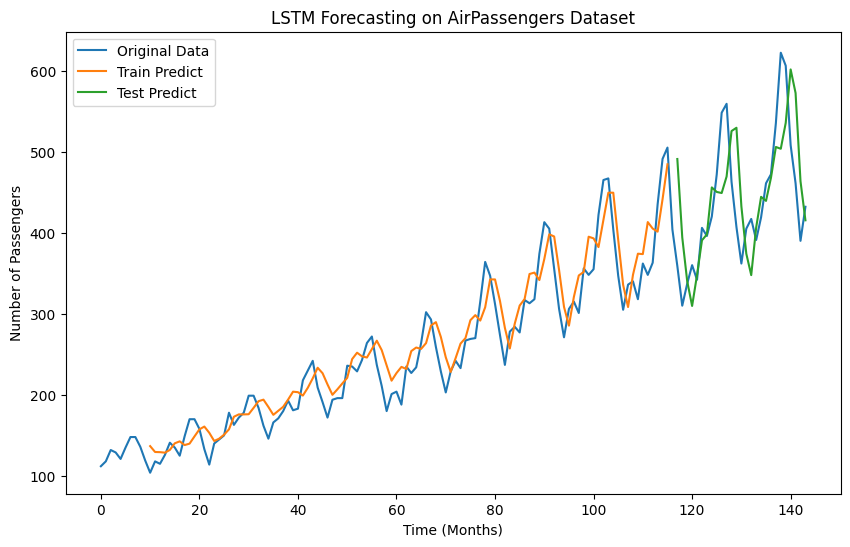

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import math

# 1. Load dataset
df = pd.read_csv("/content/AirPassengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
data = df['#Passengers'].values.reshape(-1, 1)

# 2. Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Convert to sequences
def create_dataset(dataset, time_step=10):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        X.append(a)
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# 4. Split into train and test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, verbose=1)

# 6. Predict and inverse transform
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform([y_train])
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform([y_test])

# 7. Calculate RMSE
train_rmse = math.sqrt(mean_squared_error(y_train_inv[0], train_predict[:, 0]))
test_rmse = math.sqrt(mean_squared_error(y_test_inv[0], test_predict[:, 0]))
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

# 8. Plot predictions
plt.figure(figsize=(10, 6))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Data')

# Plot train predictions
train_predict_plot = np.empty_like(scaled_data)
train_predict_plot[:, :] = np.nan
train_predict_plot[time_step:train_size + time_step, 0] = train_predict[:, 0]
plt.plot(train_predict_plot, label='Train Predict')

# Plot test predictions
test_predict_plot = np.empty_like(scaled_data)
test_predict_plot[:, :] = np.nan
test_start = train_size + (time_step * 1) + 1
test_predict_plot[test_start:test_start + len(test_predict), 0] = test_predict[:, 0]
plt.plot(test_predict_plot, label='Test Predict')

plt.title("LSTM Forecasting on AirPassengers Dataset")
plt.xlabel("Time (Months)")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()